# Домашнее задание: модели классификации и оценка их качества.

Будем тренироваться обучать модели классификации и интерпретировать их качество.

## Часть 1. Обучение моделей классификации (5 баллов).

Поработайте с датасетом telecom_churn. Вам предстоит по характеристикам клиента предсказать, уйдет он или нет (целевая колонка - Churn).

A. Решите задачу с помощью логистической регрессии:
- подберите значение гиперпараметров с помощью GridSearchCV
Что вы можете сказать об алгоритме? Он переобучился/недообучился/обучился как надо и вы довольны качеством?

B. Решите задачу с помощью метода опорных векторов (с kernel = 'linear'):
- подберите значение гиперпараметров с помощью GridSearchCV
Что вы можете сказать об алгоритме? Он переобучился/недообучился/обучился как надо и вы довольны качеством?

Не забудьте масштабировать данные перед применением линейных моделей.

C. Попробуйте увеличить число признаков с помощью добавления полиномиальных признаков. Также можно добавить функции от признаков вручную (те, которые вам кажутся подходящими в данной задаче).
Улучшилось ли качество алгоритма?

D. Постройте матрицу корреляций признаков. Есть ли признаки, которые практически не коррелируют с целевой переменной? Попробуйте их удалить. Есть ли пары сильно коррелирующих между собой признаков? Удалите по одному признаку из каждой пары.
Помогло ли это улучшить качество в данной задаче?

Пункты C и D можно скомбинировать для достижения наилучшего качества.

E. Сделайте мини-отчет о проведенной работе. Для этого ответьте на вопросы:
a) какой классификатор дал наилучший результат? чему равны значения метрик accuracy, f1-score и ROC-AUC?
(Вы можете изначально разбить данные на train и test и сравнивать значения метрик на этих выборках; или же можно оценивать качество алгоритмов по кросс-валидации).

b) какие новые признаки вы добавили и какие признаки удалили?

c) удалось ли добиться того, что алгоритм не переобучился и не недообучился?

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['rec', 'poly']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


LogReg:
Accuracy: 0.8590704647676162
F1: 0.22950819672131148
ROC-AUC: 0.809839030566106
SVM:
Accuracy: 0.8545727136431784
F1: 0.0
ROC-AUC: 0.7341472237294266
LogReg + Poly:
Accuracy: 0.841079460269865
F1: 0.46464646464646464
ROC-AUC: 0.8166576234400434


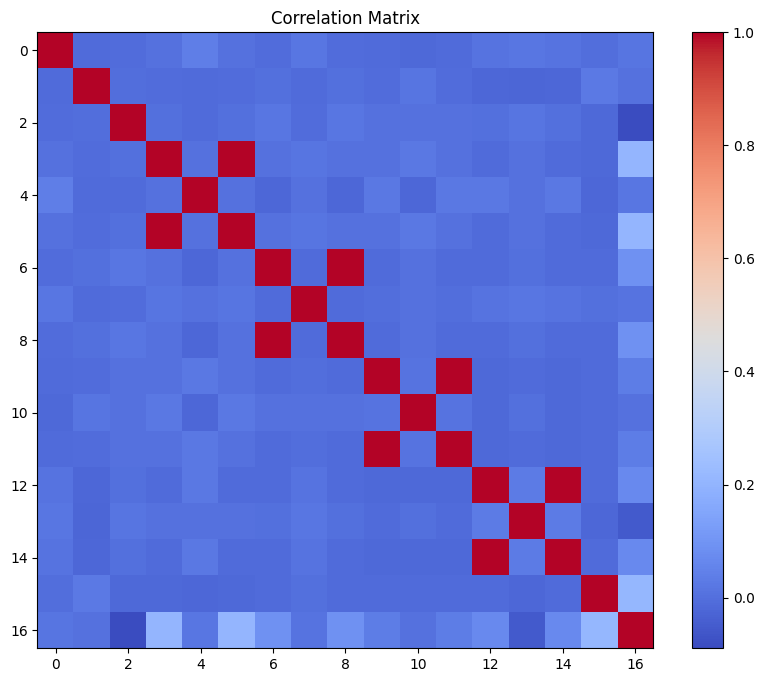

После удаления признаков:
Accuracy: 0.8650674662668666
F1: 0.3835616438356164
ROC-AUC: 0.8029300054259361


In [56]:
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline

df = pd.read_csv('telecom_churn.csv')

y = df['Churn']
X = df.drop('Churn', axis=1)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

params_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2']
}

grid_lr = GridSearchCV(pipe_lr, params_lr, cv=5, scoring='roc_auc')
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print("LogReg:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='linear', probability=True))
])

params_svm = {
    'model__C': [0.01, 0.1, 1, 10]
}

grid_svm = GridSearchCV(pipe_svm, params_svm, cv=5, scoring='roc_auc')
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]

print("SVM:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_svm))

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

lr_poly = LogisticRegression(max_iter=1000)
lr_poly.fit(X_train_poly, y_train)

y_pred_poly = lr_poly.predict(X_test_poly)
y_proba_poly = lr_poly.predict_proba(X_test_poly)[:, 1]

print("LogReg + Poly:")
print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print("F1:", f1_score(y_test, y_pred_poly))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_poly))

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

target_corr = corr['Churn'].abs()
low_corr_features = target_corr[target_corr < 0.01].index

X_reduced = X.drop(columns=[col for col in low_corr_features if col in X.columns])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

pipe_lr.fit(X_train_r, y_train_r)

y_pred_r = pipe_lr.predict(X_test_r)
y_proba_r = pipe_lr.predict_proba(X_test_r)[:, 1]

print("После удаления признаков:")
print("Accuracy:", accuracy_score(y_test_r, y_pred_r))
print("F1:", f1_score(y_test_r, y_pred_r))
print("ROC-AUC:", roc_auc_score(y_test_r, y_proba_r))

Ваш отчет здесь.

## Часть 2. Оценка качества моделей классификации (5 баллов).

* Колонки 0, 1, ..., 13 - анонимизированные характеристики клиентов (некоторые числовые, некоторые категориальные).
* Target - целевая переменная: 1 - выдать кредит, 0 - не выдать кредит.

На этих данных было обучено три различных алгоритма классификации и получены предсказания:
* pred1_probs - предсказанные вероятности положительного класса, полученные алгоритмом 1.
* pred1_classes - предсказанные алгоритмом 1 классы
* pred2_probs, pred2_classes, pred3_probs, pred3_classes - аналогичные величины для алгоритмов 2 и 3

Наша задача - оценить качество каждого из трех алгоритмов и разобраться, какой из алгоритмов лучше всего работает в данной задаче.

In [57]:
df = pd.read_csv("credit_scoring_example1.csv")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,target,pred1_probs,pred1_classes,pred2_probs,pred2_classes,pred3_probs,pred3_classes
0,1,22.08,11.46,2,4,4,1.585,0,0,0,...,2,100,1213,0,0.506772,1,0.610853,1,0.375494,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,...,2,160,1,0,0.358519,0,0.185941,0,0.200975,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,...,2,280,1,0,0.358753,0,0.523009,1,0.160465,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,...,2,0,1,1,0.408729,0,0.185941,0,0.357771,0
4,1,20.17,8.17,2,6,4,1.960,1,1,14,...,2,60,159,1,0.480904,0,0.526646,1,0.260169,0


In [58]:
df.shape

(689, 21)

**Задание 1.** Проверьте target на сбалансированность по классам, сделайте вывод.

In [59]:
df["target"].value_counts(normalize=True)

,proportion
target,
0,0.554427
1,0.445573


**Задание 2.** Вычислите accuracy - долю правильных ответов каждого из алгоритмов. Какой алгоритм имеет наибольшую accuracy?

In [60]:
acc1 = accuracy_score(y_true, df['pred1_classes'])
acc2 = accuracy_score(y_true, df['pred2_classes'])
acc3 = accuracy_score(y_true, df['pred3_classes'])

print("Accuracy алгоритма 1:", acc1)
print("Accuracy алгоритма 2:", acc2)
print("Accuracy алгоритма 3:", acc3)

best_acc = max([acc1, acc2, acc3])

if best_acc == acc1:
    print("Лучший по accuracy: алгоритм 1")
elif best_acc == acc2:
    print("Лучший по accuracy: алгоритм 2")
else:
    print("Лучший по accuracy: алгоритм 3")

Accuracy алгоритма 1: 0.6618287373004355
Accuracy алгоритма 2: 0.6719883889695211
Accuracy алгоритма 3: 0.6400580551523948
Лучший по accuracy: алгоритм 2


**Задание 3.** Теперь вычислите точность и полноту каждого из алгоритмов.

In [61]:
from sklearn.metrics import precision_score, recall_score

y_true = df['target']

precision1 = precision_score(y_true, df['pred1_classes'])
recall1 = recall_score(y_true, df['pred1_classes'])

precision2 = precision_score(y_true, df['pred2_classes'])
recall2 = recall_score(y_true, df['pred2_classes'])

precision3 = precision_score(y_true, df['pred3_classes'])
recall3 = recall_score(y_true, df['pred3_classes'])

print("Алгоритм 1: precision =", precision1, ", recall =", recall1)
print("Алгоритм 2: precision =", precision2, ", recall =", recall2)
print("Алгоритм 3: precision =", precision3, ", recall =", recall3)

Алгоритм 1: precision = 0.6907216494845361 , recall = 0.4364820846905538
Алгоритм 2: precision = 0.6103542234332425 , recall = 0.7296416938110749
Алгоритм 3: precision = 0.6903225806451613 , recall = 0.3485342019543974


Самым полезным инструментом в практических задачах является ***матрица ошибок***. Смотря на неё и регулируя порог, определяющий классы, мы можем достичь оптимального решения нашей задачи.

**Задание 4.** Используя функцию plot_confusion_matrix для визуализации матрицы ошибок, нарисуйте матрицы ошибок всех трех алгоритмов.

In [62]:
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

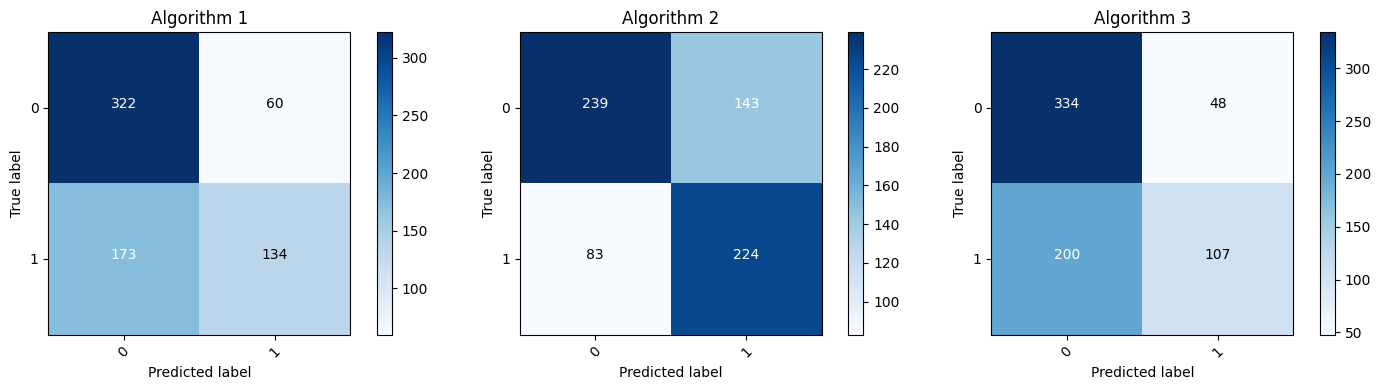

In [63]:
y_true = df['target']

cm1 = confusion_matrix(y_true, df['pred1_classes'])
cm2 = confusion_matrix(y_true, df['pred2_classes'])
cm3 = confusion_matrix(y_true, df['pred3_classes'])

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plot_confusion_matrix(cm1, classes=[0, 1], title='Algorithm 1')

plt.subplot(1, 3, 2)
plot_confusion_matrix(cm2, classes=[0, 1], title='Algorithm 2')

plt.subplot(1, 3, 3)
plot_confusion_matrix(cm3, classes=[0, 1], title='Algorithm 3')

plt.show()

Давайте определимся с целями нашего предсказания:
    
* **Вариант 1**: хотим выдать кредит максимальному числу людей среди тех, кто мог бы его вернуть. При этом не хотим много ошибаться (общее число ошибок не более 35%).
  
1) Мы не хотим, чтобы алгоритм много ошибался: accuracy $\geq$ 0.65.

2) Кроме того полнота должна быть как можно больше (число в левом нижнем квадрате матрицы ошибок минимально).

**Задание 5.** Для каждого алгоритма найдите такой порог принятия решения, чтобы выполнялись перечисленные выше условия. Какой максимальной полноты можно добиться у каждой из моделей при условии, что accuracy $\geq$ 0.65?

**Комментарий:** порог можно искать в цикле с небольшим шагом.

In [64]:
def find_best_threshold(probs, y_true):
    thresholds = np.arange(0, 1.01, 0.01)

    best_recall = 0
    best_threshold = 0

    for t in thresholds:
        y_pred = (probs >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)

        if acc >= 0.65 and rec > best_recall:
            best_recall = rec
            best_threshold = t

    return best_threshold, best_recall

t1, r1 = find_best_threshold(df['pred1_probs'], y_true)
t2, r2 = find_best_threshold(df['pred2_probs'], y_true)
t3, r3 = find_best_threshold(df['pred3_probs'], y_true)

print("Алгоритм 1: лучший порог =", t1, ", recall =", r1)
print("Алгоритм 2: лучший порог =", t2, ", recall =", r2)
print("Алгоритм 3: лучший порог =", t3, ", recall =", r3)

Алгоритм 1: лучший порог = 0.36 , recall = 0.742671009771987
Алгоритм 2: лучший порог = 0.27 , recall = 0.8371335504885994
Алгоритм 3: лучший порог = 0 , recall = 0


**Задание 6.** Визуализируйте матрицу ошибок для каждого из трех алгоритмов с подобранным порогом.

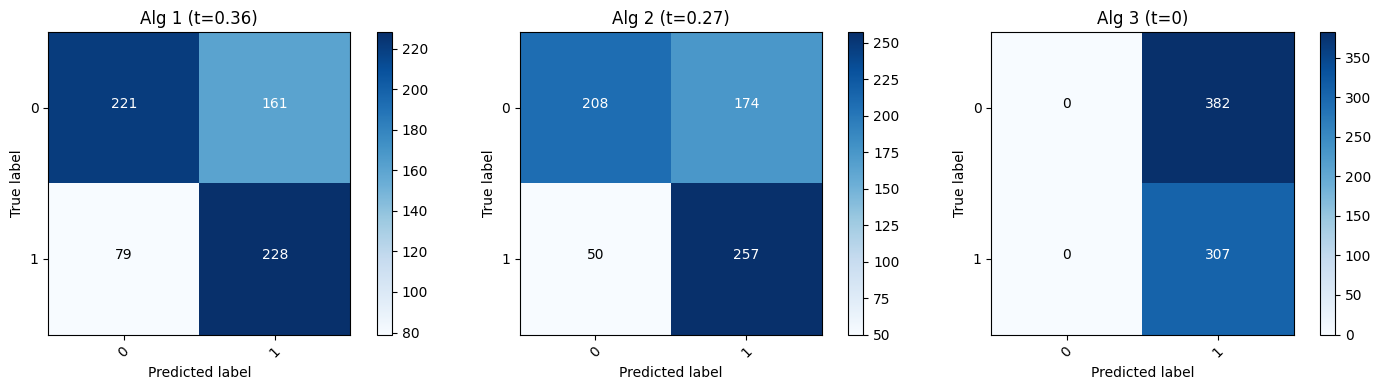

In [65]:
y_true = df['target']

y1_new = (df['pred1_probs'] >= t1).astype(int)
y2_new = (df['pred2_probs'] >= t2).astype(int)
y3_new = (df['pred3_probs'] >= t3).astype(int)

cm1 = confusion_matrix(y_true, y1_new)
cm2 = confusion_matrix(y_true, y2_new)
cm3 = confusion_matrix(y_true, y3_new)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plot_confusion_matrix(cm1, classes=[0, 1], title=f'Alg 1 (t={t1})')

plt.subplot(1, 3, 2)
plot_confusion_matrix(cm2, classes=[0, 1], title=f'Alg 2 (t={t2})')

plt.subplot(1, 3, 3)
plot_confusion_matrix(cm3, classes=[0, 1], title=f'Alg 3 (t={t3})')

plt.show()

**Выводы:** здесь напишите, какая модель лучше всего справилась с поставленной задачей.

Наша цель может звучать и по-другому:
    
* **Вариант 2**: среди тех, кому модель выдает кредит, должно быть меньше всего ошибок (мало людей, кто его на самом деле не вернет - на них будем терять деньги).
    При этом не хотим много ошибаться (общее число ошибок не более 35%).
  
1) Мы не хотим, чтобы алгоритм много ошибался: accuracy $\geq$ 0.65.

2) Кроме того точность должна быть как можно больше (число в правом верхнем квадрате матрицы ошибок минимально).

**Задание 7.** Для каждого алгоритма найдите порог принятия решения, чтобы выполнялись перечисленные выше условия. Какой максимальной точности можно добиться у каждой из моделей при условии, что accuracy $\geq$ 0.65?

In [66]:
y_true = df['target']

def find_best_threshold_precision(probs, y_true):
    thresholds = np.arange(0, 1.01, 0.01)

    best_precision = 0
    best_threshold = 0

    for t in thresholds:
        y_pred = (probs >= t).astype(int)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)

        if acc >= 0.65 and prec > best_precision:
            best_precision = prec
            best_threshold = t

    return best_threshold, best_precision

t1_p, p1 = find_best_threshold_precision(df['pred1_probs'], y_true)
t2_p, p2 = find_best_threshold_precision(df['pred2_probs'], y_true)
t3_p, p3 = find_best_threshold_precision(df['pred3_probs'], y_true)

print("Алгоритм 1: threshold =", t1_p, ", precision =", p1)
print("Алгоритм 2: threshold =", t2_p, ", precision =", p2)
print("Алгоритм 3: threshold =", t3_p, ", precision =", p3)

Алгоритм 1: threshold = 0.54 , precision = 0.7371794871794872
Алгоритм 2: threshold = 0.73 , precision = 0.8367346938775511
Алгоритм 3: threshold = 0 , precision = 0


**Задание 8.** Нарисуйте матрицы ошибок для каждого из алгоритмов с найденными значениями порога. Какая модель лучше всех справилась с этой задачей?

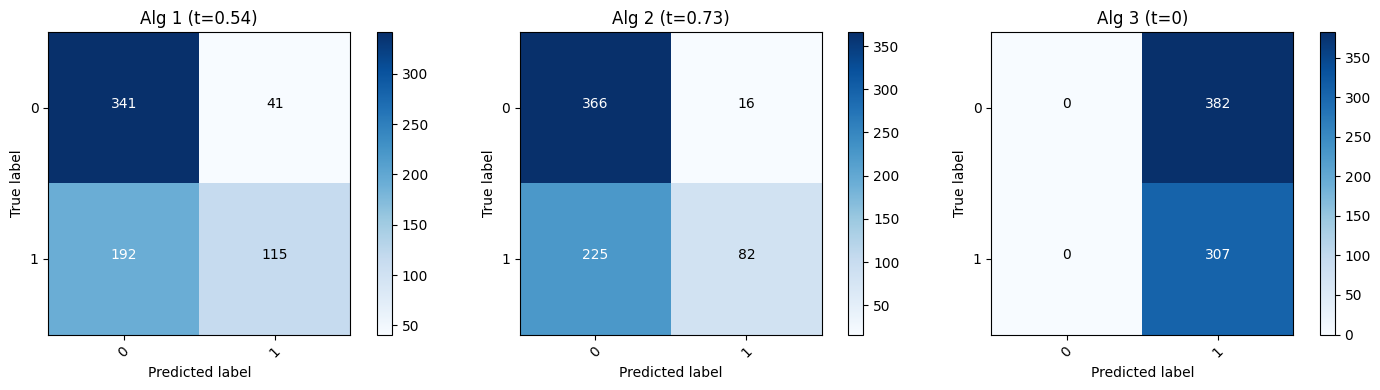

In [67]:
y_true = df['target']

y1_new_p = (df['pred1_probs'] >= t1_p).astype(int)
y2_new_p = (df['pred2_probs'] >= t2_p).astype(int)
y3_new_p = (df['pred3_probs'] >= t3_p).astype(int)

cm1 = confusion_matrix(y_true, y1_new_p)
cm2 = confusion_matrix(y_true, y2_new_p)
cm3 = confusion_matrix(y_true, y3_new_p)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plot_confusion_matrix(cm1, classes=[0, 1], title=f'Alg 1 (t={t1_p})')

plt.subplot(1, 3, 2)
plot_confusion_matrix(cm2, classes=[0, 1], title=f'Alg 2 (t={t2_p})')

plt.subplot(1, 3, 3)
plot_confusion_matrix(cm3, classes=[0, 1], title=f'Alg 3 (t={t3_p})')

plt.show()

Также (**Вариант 3**) можно потребовать, чтобы и точность, и полнота были высокими, то есть обе ошибки в матрице ошибок были маленькие. Как вариант - можно максимизировать F1-score (среднее гармоническое между точностью и полнотой).

**Задание 9.** Найдите пороги для достижения максимального F1-score для каждой из трех моделей и нарисуйте матрицы ошибок. Какая модель решает поставленную задачу лучше остальных?

Alg1: 0.34 0.672
Alg2: 0.32 0.6990291262135923
Alg3: 0.15 0.6443418013856813


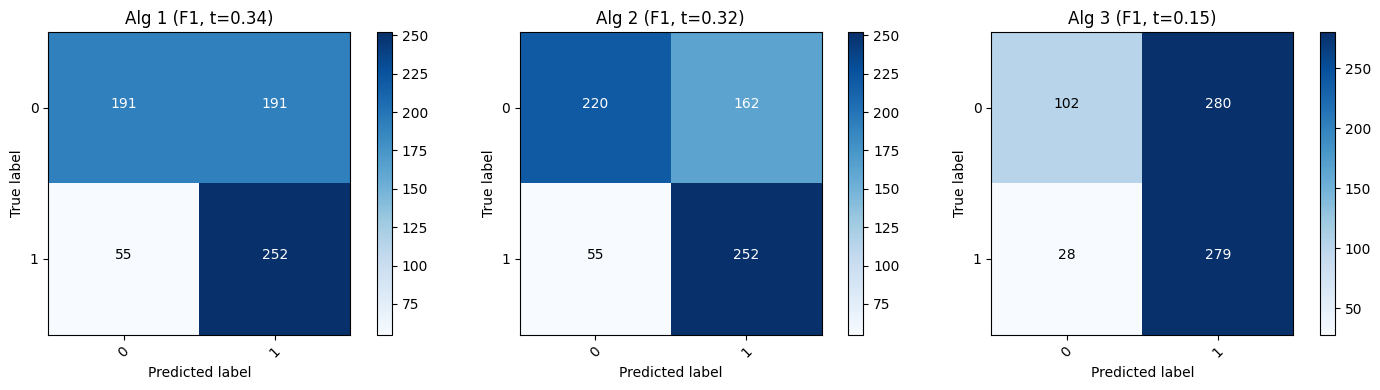

In [68]:
y_true = df['target']

def find_best_threshold_f1(probs, y_true):
    thresholds = np.arange(0, 1.01, 0.01)

    best_f1 = 0
    best_threshold = 0

    for t in thresholds:
        y_pred = (probs >= t).astype(int)
        f1 = f1_score(y_true, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, best_f1


t1_f1, f1_1 = find_best_threshold_f1(df['pred1_probs'], y_true)
t2_f1, f1_2 = find_best_threshold_f1(df['pred2_probs'], y_true)
t3_f1, f1_3 = find_best_threshold_f1(df['pred3_probs'], y_true)

print("Alg1:", t1_f1, f1_1)
print("Alg2:", t2_f1, f1_2)
print("Alg3:", t3_f1, f1_3)


y1_f1 = (df['pred1_probs'] >= t1_f1).astype(int)
y2_f1 = (df['pred2_probs'] >= t2_f1).astype(int)
y3_f1 = (df['pred3_probs'] >= t3_f1).astype(int)

cm1 = confusion_matrix(y_true, y1_f1)
cm2 = confusion_matrix(y_true, y2_f1)
cm3 = confusion_matrix(y_true, y3_f1)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plot_confusion_matrix(cm1, classes=[0, 1], title=f'Alg 1 (F1, t={t1_f1})')

plt.subplot(1, 3, 2)
plot_confusion_matrix(cm2, classes=[0, 1], title=f'Alg 2 (F1, t={t2_f1})')

plt.subplot(1, 3, 3)
plot_confusion_matrix(cm3, classes=[0, 1], title=f'Alg 3 (F1, t={t3_f1})')

plt.show()

#### Кстати

В python есть удобная функция classification_report, которая выводит значения нескольких метрик.

In [69]:
from sklearn.metrics import classification_report

print(classification_report(df['target'],df['pred1_classes']))

              precision    recall  f1-score   support

           0       0.65      0.84      0.73       382
           1       0.69      0.44      0.53       307

    accuracy                           0.66       689
   macro avg       0.67      0.64      0.63       689
weighted avg       0.67      0.66      0.65       689



### Обучим свою модель для предсказания target.

**Задание 10.** Отнормируйте признаки в задаче и обучите логистическую регрессию предсказывать target.

In [70]:
df = pd.read_csv("credit_scoring_example1.csv")

X = df.drop(columns=['target'])
y = df['target']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        77
           1       0.81      0.90      0.85        61

    accuracy                           0.86       138
   macro avg       0.86      0.87      0.86       138
weighted avg       0.87      0.86      0.86       138



**Задание 11.** Подберите порог для перевода предсказания в классы, чтобы максимизировать:
    а) точность
    б) полноту
    в) f1-score.
Лучше ли логистическая регрессия справилась с задачей, чем три готовые модели, предсказания которых мы анализировали выше?

In [71]:
probs = model.predict_proba(X_test_scaled)[:, 1]
y_true = y_test

thresholds = np.arange(0, 1.01, 0.01)

best_precision = (0, 0)
best_recall = (0, 0)
best_f1 = (0, 0)

for t in thresholds:
    y_pred = (probs >= t).astype(int)

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    if prec > best_precision[1]:
        best_precision = (t, prec)

    if rec > best_recall[1]:
        best_recall = (t, rec)

    if f1 > best_f1[1]:
        best_f1 = (t, f1)

print("Best Precision:", best_precision)
print("Best Recall:", best_recall)
print("Best F1:", best_f1)

Best Precision: (np.float64(0.91), 1.0)
Best Recall: (np.float64(0.0), 1.0)
Best F1: (np.float64(0.58), 0.8760330578512396)
